## Travel Planning Agent

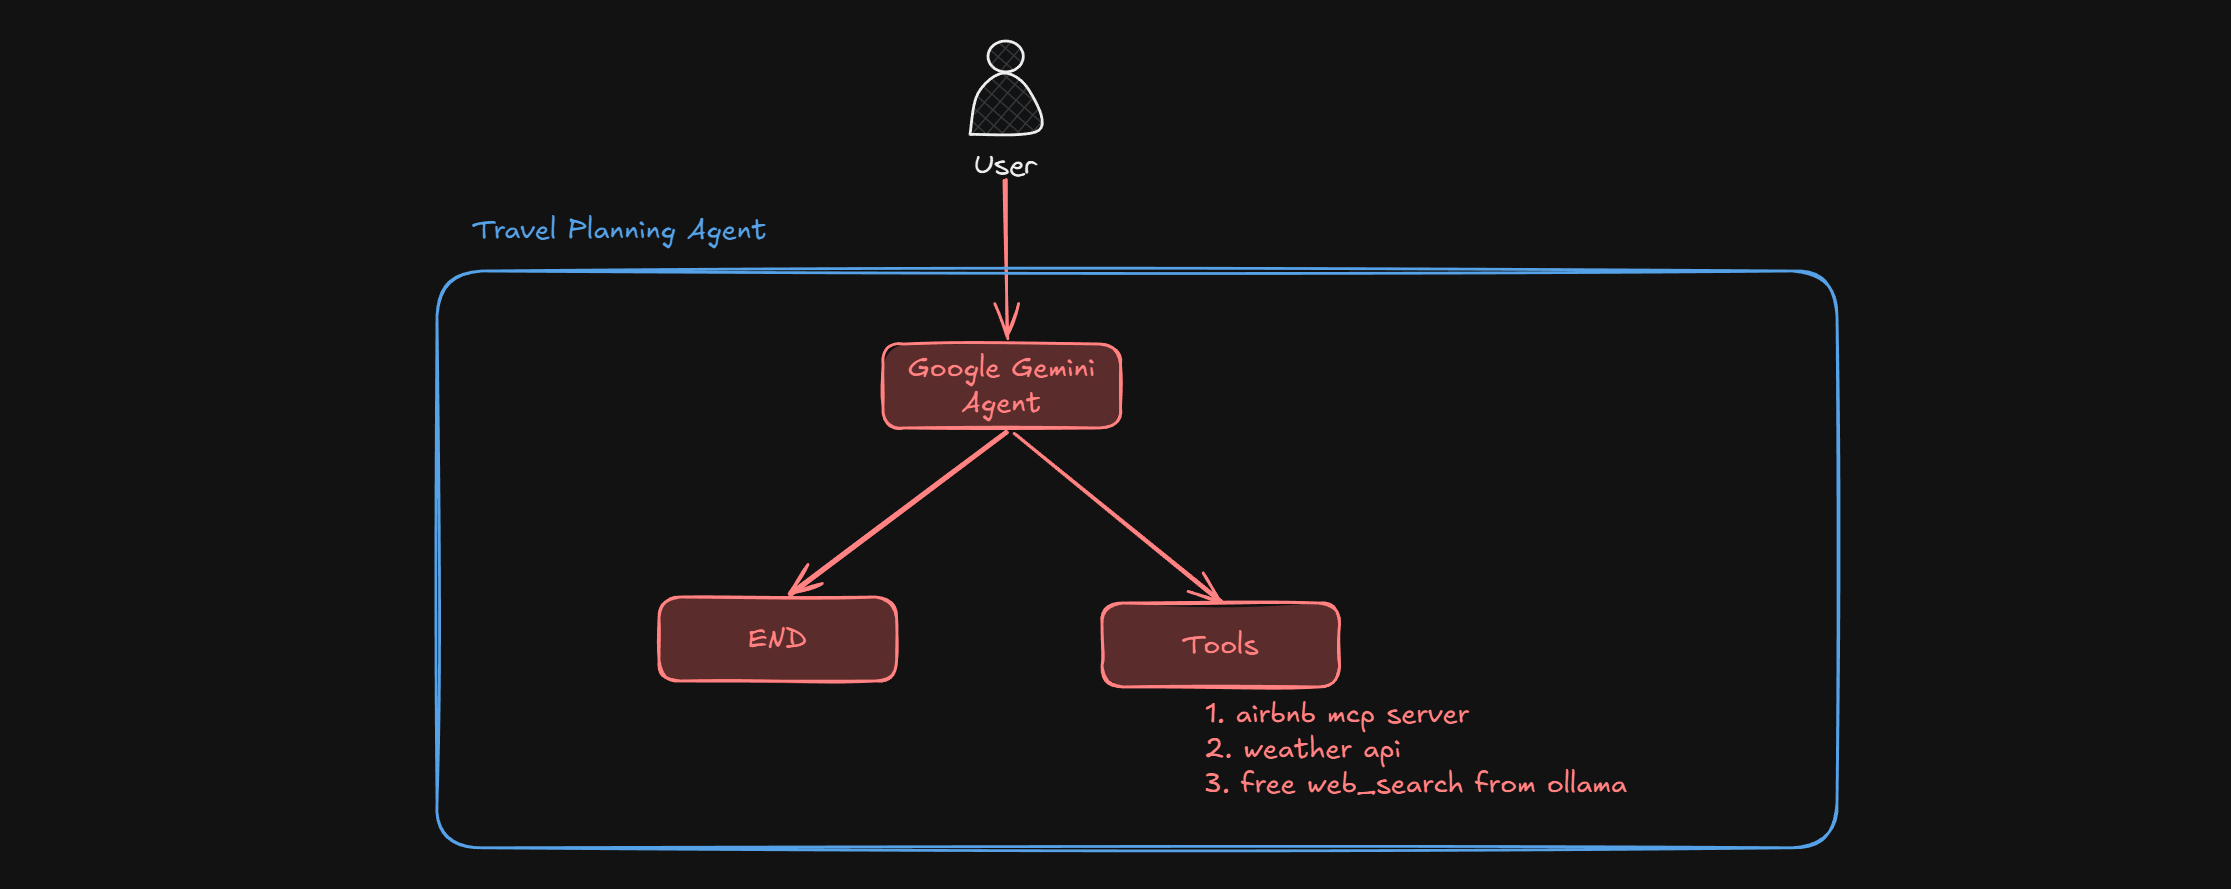

Links
- https://github.com/openbnb-org/mcp-server-airbnb
- https://www.weatherapi.com/my/
- https://ollama.com/settings/keys
- https://aistudio.google.com/api-keys

In [ ]:
from dotenv import load_dotenv
load_dotenv()

from langchain_google_genai import ChatGoogleGenerativeAI

from langchain.agents import create_agent
from langchain_core.tools import tool

import ollama 
import json
import requests

In [ ]:
@tool
def web_search(query: str) -> str:
    """
    Perform a live web search using Ollama Cloud Web Search API.
    Input: query string
    Output: formatted JSON string
    """
    response = ollama.web_search(query, max_results=2)
    return response.results

response = web_search.invoke({"query": "best travel destinations in Europe"})

In [ ]:
response

In [ ]:
import requests
from langchain_core.tools import tool
import os

@tool
def get_weather(location: str) -> str:
    """Get current weather for a location using WeatherAPI.com.
    
    Use for queries about weather, temperature, or conditions in any city.
    Examples: "weather in Paris", "temperature in Tokyo", "is it raining in London"
    
    Args:
        location: City name (e.g., "New York", "London", "Tokyo")
        
    Returns:
        Current weather information including temperature and conditions.
    """

    url = (
        "http://api.weatherapi.com/v1/current.json"
        f"?key={os.getenv("WEATHER_API_KEY")}&q={location}&aqi=no"
    )

    response = requests.get(url, timeout=10)
    response.raise_for_status()

    data = response.json()
    return data


# Test
response = get_weather.invoke({"location": "Paris"})
print(response)


In [ ]:
import subprocess
import sys

@tool
def hotel_search(query):
    """Search for hotels using Airbnb MCP async function."""

    code = f"""
import asyncio
from airbnb_mcp import hotel_search
asyncio.run(hotel_search("{query}"))
"""
    
    result = subprocess.run([sys.executable, '-c', code], capture_output=True, text=True)

    return result.stdout

In [ ]:
query = "show me the best hotels in mumbai"
response = hotel_search.invoke({"query": query})

print(response)

### Travel Agent with Google Gemini

In [ ]:
# Initialize the LLM
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.7)

In [ ]:
# Combine all tools
tools = [web_search, get_weather, hotel_search]

In [ ]:
system_prompt = """You are an expert travel planner with access to:
- web_search(query)
- get_weather(location)
- hotel_search(query)

Goal: Create personalized, realistic itineraries using real-time data.

### Workflow
1. Understand destination, duration (default 5 days), budget, interests, and special needs.
2. Research using multiple web searches (attractions, guides, tips, hidden gems). Check weather.
3. Find accommodations based on budget, area, and proximity.
4. Build day-by-day plan with activities, food, timings, distances, and transport tips.
5. Add weather notes, packing list, budget estimate, local customs, safety, transport options.
6. Present final plan clearly in Markdown: title, duration, daily schedule, hotels, weather, budget, tips, useful links.

### Rules
- Use 3+ web searches.
- Always check weather.
- Provide specific names, places, and timings.
- Keep itinerary realistic and current.
- If duration missing → make a 5-day plan."""

In [ ]:
# Create the travel planning agent
travel_agent = create_agent(model=llm, tools=tools, system_prompt=system_prompt)

### Test the Travel Planning Agent

In [ ]:
from langchain_core.messages import HumanMessage

# Example query - you can modify this
query = "Plan a 3-day trip to Mumbai for solo traveler"

# Invoke the agent
response = travel_agent.invoke({'messages': [HumanMessage(content=query)]})

In [ ]:
# Display the travel plan
response = response['messages'][-1].content[0]['text']

In [ ]:
with open("travel_plan.md", "w", encoding="utf-8") as f:
    f.write(response)

In [ ]:
# display the response in markdown format
from IPython.display import Markdown, display
display(Markdown(response))